## 1. Import Libraries :-

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn libraries for machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For saving the model
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset :-

In [4]:
# Load the dataset
df = pd.read_csv(r"..\dataset\amazon.csv")

In [5]:
# Check first 5 rows
display(df.head())

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [6]:
# Check basic info and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [7]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


## 3. Data Cleaning & Preprocessing :-

In [8]:
# 1. rating_count column me 2 missing values hain, unko drop kar dete hain
df = df.dropna(subset=['rating_count'])

In [9]:
# 2. 'rating' column me ek jagah '|' symbol hai galti se, usko replace karke numeric banate hain
df['rating'] = df['rating'].replace('|', np.nan)
df = df.dropna(subset=['rating']) # drop that 1 row
df['rating'] = df['rating'].astype(float)

In [10]:
# 3. Prices me se ₹ aur comma (,) hata kar float me convert karte hain
def clean_price(x):
    if isinstance(x, str):
        x = x.replace('₹', '').replace(',', '')
        return float(x)
    return x

df['discounted_price'] = df['discounted_price'].apply(clean_price)
df['actual_price'] = df['actual_price'].apply(clean_price)

In [11]:
# 4. Discount percentage me se % hata kar float me convert karte hain
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float) / 100

In [12]:
# 5. Rating count me se comma (,) hata kar integer me convert karte hain
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(int)

In [13]:
# Calculate the 95th percentile of rating_count
upper_limit = df['rating_count'].quantile(0.95)

# Keep only the rows where demand is below this extreme limit
df = df[df['rating_count'] <= upper_limit]

In [14]:
# 7. Extract Main Category and apply One-Hot Encoding
df['main_category'] = df['category'].apply(lambda x: str(x).split('|')[0])
# Get Top 5 categories to avoid creating too many empty columns (improves model logic)
top_categories = df['main_category'].value_counts().nlargest(5).index
df['main_category'] = df['main_category'].apply(lambda x: x if x in top_categories else 'Other')

# One-Hot Encode
df = pd.get_dummies(df, columns=['main_category'], drop_first=True)

In [15]:
print("Data cleaning successful! Updated Data Types:")
print(df[['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']].dtypes)

Data cleaning successful! Updated Data Types:
discounted_price       float64
actual_price           float64
discount_percentage    float64
rating                 float64
rating_count             int32
dtype: object


In [16]:
df.shape

(1388, 21)

## 4. Exploratory Data Analysis (EDA) :-

In [17]:
# Dataset ke numerical columns select karte hain
num_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']
df_num = df[num_cols]

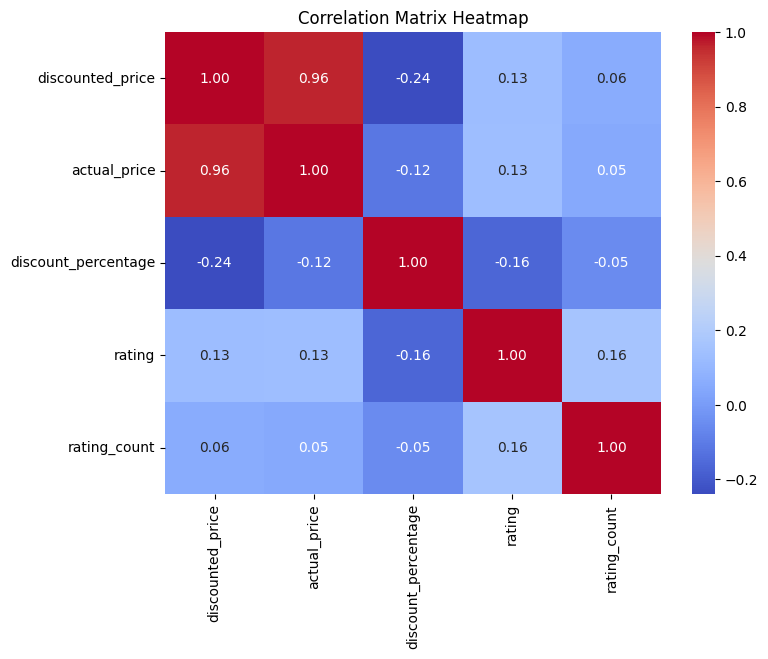

In [18]:
# 1. Correlation Matrix Heatmap (Dekhne ke liye ki kon sa feature demand se related hai)
# Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

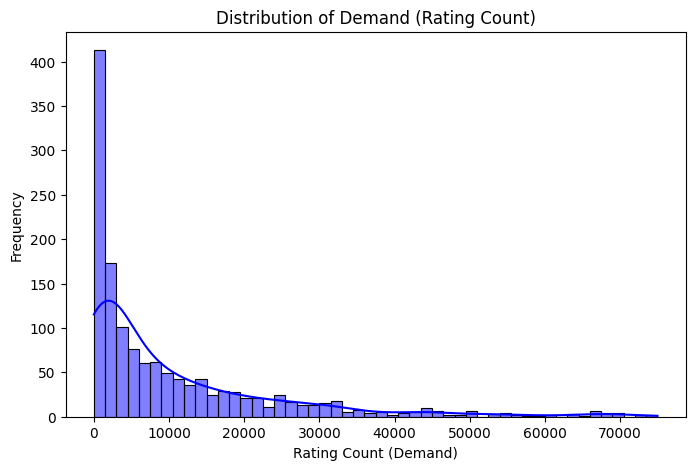

In [19]:
# 2. Target Variable (rating_count) ka distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['rating_count'], bins=50, kde=True, color='blue')
plt.title("Distribution of Demand (Rating Count)")
plt.xlabel("Rating Count (Demand)")
plt.ylabel("Frequency")
plt.show()

## 5. Feature Selection :-

In [20]:
feature_columns = ['discounted_price', 'actual_price', 'discount_percentage', 'rating'] + \
                  [col for col in df.columns if 'main_category_' in col]

X = df[feature_columns]
y = np.log1p(df['rating_count']) # Log transformation to handle skewed demand

In [21]:
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1388, 9)
Target (y) shape: (1388,)


## 6 & 7. Train-Test Split & Scaling :-

In [22]:
# 80% data training ke liye aur 20% testing ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Feature Scaling (Kyonki price aur rating ke scale alag alag hain)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
print("Training Data Size:", X_train_scaled.shape)
print("Testing Data Size:", X_test_scaled.shape)

Training Data Size: (1110, 9)
Testing Data Size: (278, 9)


## 8 & 9. Model Training & Evaluation :-

In [25]:
# Hum 3 algorithms train karenge
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [26]:
# Evaluate karne ke liye ek function
def evaluate_model(y_true_log, y_pred_log, model_name):
    # Convert predictions and true values back to actual scale (normal numbers)
    y_true_actual = np.expm1(y_true_log)
    y_pred_actual = np.expm1(y_pred_log)
    
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    r2 = r2_score(y_true_actual, y_pred_actual)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}\n")
    return r2

In [27]:
# Training and Prediction loop
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train) # Train
    y_pred = model.predict(X_test_scaled) # Predict
    y_pred_log = model.predict(X_test_scaled)
    y_pred_actual = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test)
    results[name] = evaluate_model(y_test, y_pred, name) # Evaluate

--- Linear Regression ---
MAE:  8318.93
RMSE: 14879.88
R² Score: -0.0929

--- Decision Tree ---
MAE:  8428.08
RMSE: 15454.34
R² Score: -0.1789

--- Random Forest ---
MAE:  6754.21
RMSE: 12894.31
R² Score: 0.1793



In [28]:
print("Training base models...\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    evaluate_model(y_test, y_pred_log, name)

Training base models...

--- Linear Regression ---
MAE:  8318.93
RMSE: 14879.88
R² Score: -0.0929

--- Decision Tree ---
MAE:  8428.08
RMSE: 15454.34
R² Score: -0.1789

--- Random Forest ---
MAE:  6754.21
RMSE: 12894.31
R² Score: 0.1793



## 10. Hyperparameter Tuning on Best Model :-

In [29]:
print("Starting Hyperparameter Tuning for Random Forest...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate tuned model
y_pred_tuned_log = best_rf.predict(X_test_scaled)
print("\n--- Tuned Random Forest Results ---")
evaluate_model(y_test, y_pred_tuned_log, "Tuned Random Forest")

Starting Hyperparameter Tuning for Random Forest...
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

--- Tuned Random Forest Results ---
--- Tuned Random Forest ---
MAE:  7258.27
RMSE: 13621.66
R² Score: 0.0841



0.08411170026633963

## 11. Save the Model :-

In [30]:
# Best model aur Scaler ko save karenge, taaki Flask app (backend) me user inko use kar sake

joblib.dump(best_rf, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl') # Scaler save karna zaroori hai naye data ko scale karne ke liye

print("Model (model.pkl) and Scaler (scaler.pkl) saved successfully in the current folder!")

Model (model.pkl) and Scaler (scaler.pkl) saved successfully in the current folder!
